Using CNNs in place of a fully connected network.
I expect the biggest accuracy improvements in Shirts, Tshirts, Coats and Pullovers. Feedforward network treated them as a raw vector of pixels losing all the spatial information. CNNs would detect localized features like collars, buttons and overall length. Clothing items with already high accuracy from feedforward network will barely change.

In [34]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [35]:
transform = transforms.ToTensor()
train_data = datasets.FashionMNIST(
    root = 'data',
    train = True,
    download = True,
    transform = transform,
    target_transform= None
)

test_data = datasets.FashionMNIST(
    root = 'data',
    train = False,
    download = True,
    transform = transform
)

train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])
train_loader = DataLoader(train_subset, batch_size = 32, shuffle = True)
val_loader = DataLoader(val_subset, batch_size = 32, shuffle = False)
test_loader = DataLoader(test_data, batch_size = 32, shuffle = False)

class_names = train_data.classes
print(f"\nClass names: {class_names}")
print(f"Training data: {len(train_data)}\tTesting Data: {len(test_data)}")
print(f"Training batches: {len(train_loader)}\tValidation Batches: {len(val_loader)}\tTesting Batches: {len(test_loader)}")


Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Training data: 60000	Testing Data: 10000
Training batches: 1500	Validation Batches: 375	Testing Batches: 313


torch.Size([32, 1, 28, 28])


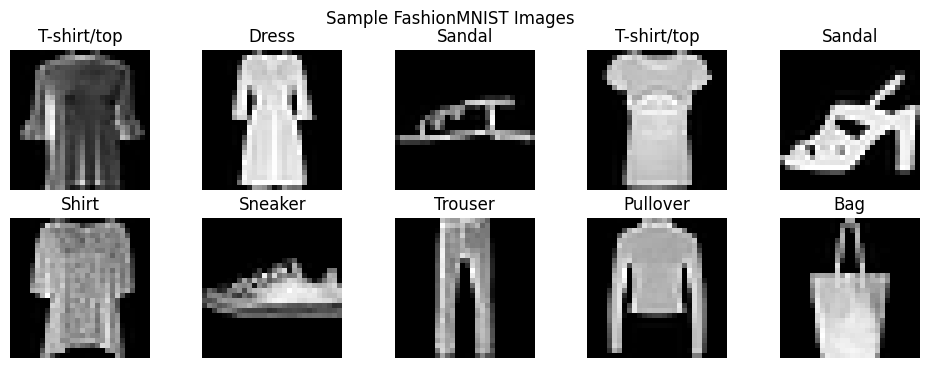

In [36]:
images, labels = next(iter(train_loader))
print(images.shape) #[N, C, H, W]

plt.figure(figsize = (12,4))
for i in range(10):
  plt.subplot(2,5, i+1)
  plt.imshow(images[i].squeeze(), cmap = 'gray')
  plt.title(class_names[labels[i]])
  plt.axis('off')

plt.suptitle('Sample FashionMNIST Images')
plt.show()

In [37]:
#building a Convolutional Neural Network
class FashionClassifier(nn.Module):
  def __init__(self):
    super().__init__()
    self.block_1 = nn.Sequential(
        nn.Conv2d(in_channels= 1,
                  out_channels= 10,
                  kernel_size = 3, #3 * 3 kernel
                  padding = 1, #this is adding one row on both sides,
                  stride = 1), #filters move by one unit horizontally and vertically
        nn.ReLU(),
        nn.Conv2d(in_channels = 10,
                  out_channels = 10,
                  kernel_size= 3,
                  padding = 1,
                  stride = 1),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size = 2, #Pooling to counter transitional invariance-> In a patch max value is recorded
                   stride = 2)

    )

    self.block_2 = nn.Sequential(
        nn.Conv2d(in_channels = 10,
                  out_channels=10,
                  kernel_size = 3,
                  padding = 1),
        nn.ReLU(),
        nn.Conv2d(in_channels=10,
                  out_channels=10,
                  kernel_size = 3,
                  padding = 1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size = 2, stride = 2)
    )

    #all the learned features will be treated as a linear unit to make that prediction
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features = 10 * 7 * 7,
                  out_features= len(class_names)) #10 classes are there

    )

  def forward(self, x):
    x = self.block_1(x)
    x= self.block_2(x)
    x = self.classifier(x)
    return x

In [38]:
torch.manual_seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = FashionClassifier().to(device)
model

FashionClassifier(
  (block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

torch.Size([1, 28, 28])


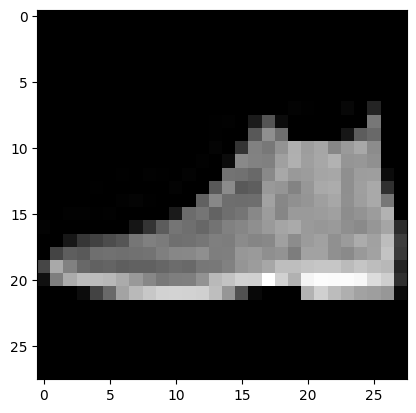

In [39]:
#how data changes as we move past our layers???
test_img = test_data[0][0]
print(test_img.shape)
plt.imshow(test_img.squeeze(), cmap = 'gray')

In [40]:
#what happens to the data as it passes through our model?
conv_layer = nn.Conv2d(in_channels = 1, out_channels = 10, kernel_size = 3, padding =1, stride = 1)
conv_img1 = conv_layer(test_img) #now we have 10 filters or neurons for the same img shape
print(conv_img1.shape)
conv_layer = nn.Conv2d(in_channels = 10, out_channels = 10, kernel_size = 3, padding =1, stride = 1)
conv_img2 = conv_layer(conv_img1)
print(conv_img2.shape)
pool_layer = nn.MaxPool2d(kernel_size = 2, stride = 2) #every 2x2 patch is converted to the max value of the patch
pool_image = pool_layer(conv_img2)
print(pool_image.shape)
conv_img3 = conv_layer(pool_image)
print(conv_img3.shape)
pool_image2 = pool_layer(conv_img3)
print(pool_image2.shape)

torch.Size([10, 28, 28])
torch.Size([10, 28, 28])
torch.Size([10, 14, 14])
torch.Size([10, 14, 14])
torch.Size([10, 7, 7])


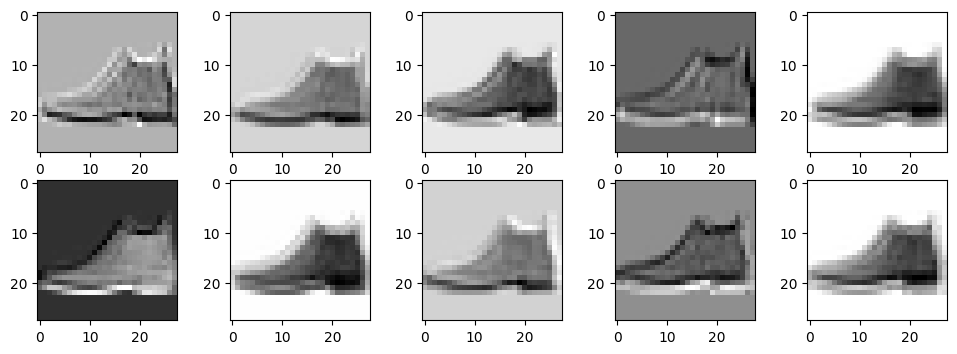

In [41]:
#lets visualize how our sample changes visually
plt.figure(figsize = (12,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(conv_img1[i].detach().numpy(), cmap = 'gray')

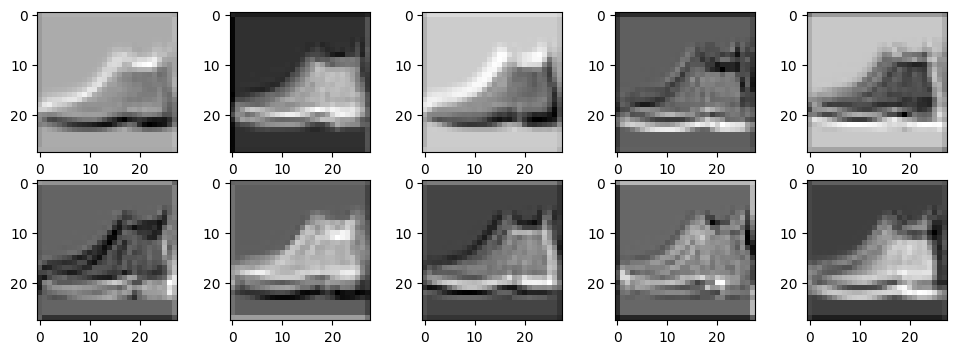

In [42]:
plt.figure(figsize = (12,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(conv_img2[i].detach().numpy(), cmap = 'gray')

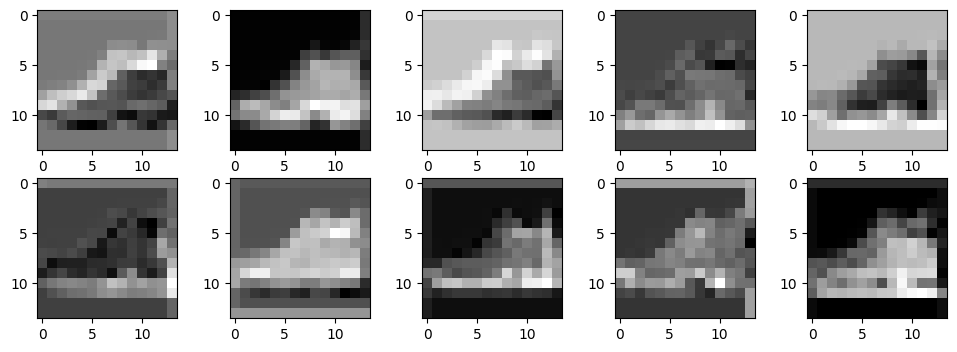

In [43]:
plt.figure(figsize = (12,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(pool_image[i].detach().numpy(), cmap = 'gray')

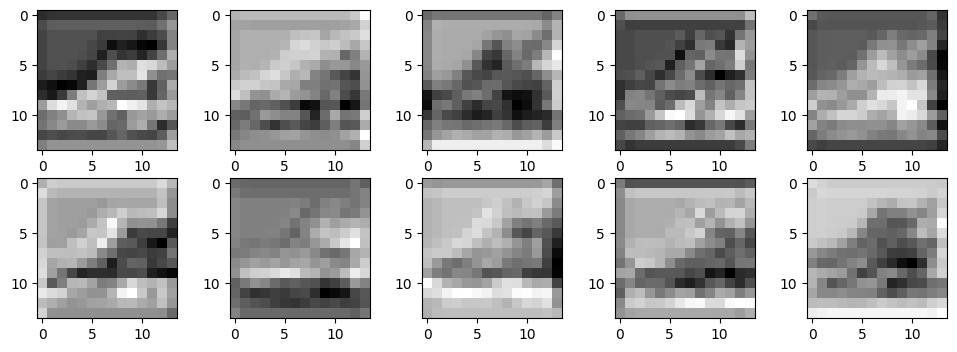

In [44]:
plt.figure(figsize = (12,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(conv_img3[i].detach().numpy(), cmap = 'gray')

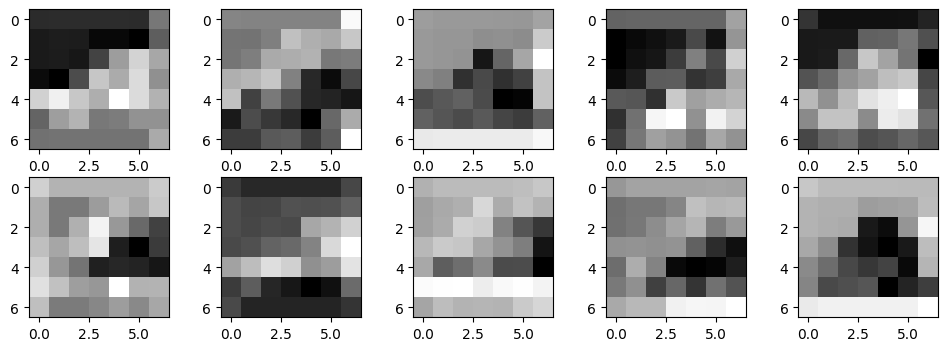

In [45]:
plt.figure(figsize = (12,4))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(pool_image2[i].detach().numpy(), cmap = 'gray')

In [46]:
#setting up the loss function and optimizer
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)


In [47]:
#training and inference_loop
torch.manual_seed(42)
epochs = 10
train_losses, val_losses, val_acc = [], [], []

for epoch in range(epochs):
  print(f"Epoch: {epoch+1}/{epochs}")
  train_loss = 0

  model.train()
  train_bar = tqdm(train_loader, desc = "Training")
  for image, label in train_bar:

    image, label = image.to(device), label.to(device)
    y_logit = model(image)
    loss = loss_fn(y_logit, label)
    train_loss += loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


  model.eval()
  val_bar = tqdm(val_loader, desc = "Validation")
  val_loss, correct, total = 0,0,0
  with torch.inference_mode():
    for image, label in val_bar:
      image, label = image.to(device), label.to(device)
      y_logit = model(image)
      y_pred = y_logit.argmax(dim = 1)
      loss = loss_fn(y_logit, label)
      val_loss += loss.item()
      correct += (y_pred == label).sum().item()
      total += label.size(0)


  train_losses.append(train_loss / len(train_loader))
  val_losses.append(val_loss/ len(val_loader))
  val_acc.append(correct/total * 100)

  print(f"Epoch {epoch+1}/10 | Train Loss: {train_losses[-1]:.4f} | Test Loss: {val_losses[-1]:.4f} | Accuracy: {val_acc[-1]:.2f}%")

Epoch: 1/10


Training:   0%|          | 0/1500 [00:00<?, ?it/s]

Validation:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 1/10 | Train Loss: 0.6463 | Test Loss: 0.3971 | Accuracy: 85.83%
Epoch: 2/10


Training:   0%|          | 0/1500 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 9/10 | Train Loss: 0.2600 | Test Loss: 0.2843 | Accuracy: 90.02%
Epoch: 10/10


Training:   0%|          | 0/1500 [00:00<?, ?it/s]

Validation:   0%|          | 0/375 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 0.2560 | Test Loss: 0.2768 | Accuracy: 90.02%


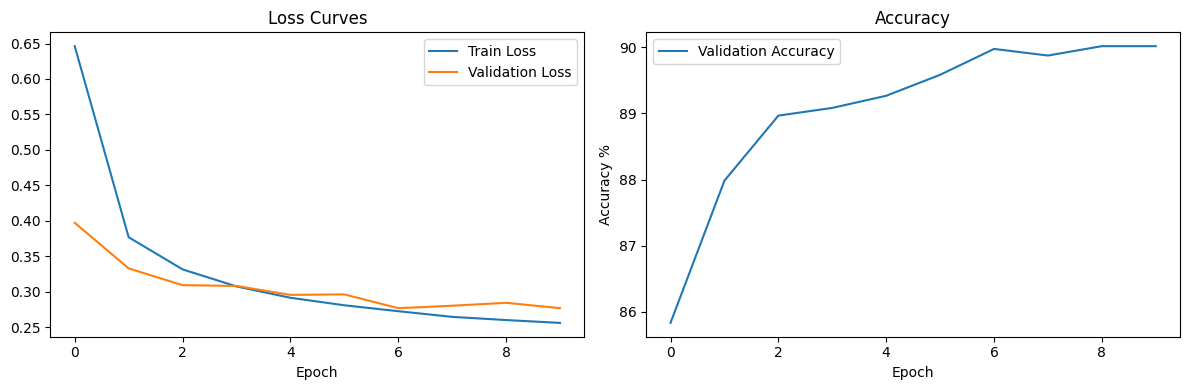

In [48]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize = (12,4))
ax1.plot(train_losses, label = 'Train Loss')
ax1.plot(val_losses, label = 'Validation Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(val_acc, label = 'Validation Accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy %')
ax2.legend()

plt.tight_layout()
plt.show()

In [49]:
#evaluating our trained model on unseen test data
model.eval()
all_preds, all_labels = [] , []
correct, total = 0,0
with torch.inference_mode():
  for image, label in test_loader:
    image = image.to(device)
    output = model(image)

    y_pred = output.argmax(dim = 1).cpu()
    correct += (y_pred == label).sum().item()
    total += label.size(0)
    all_preds.extend(y_pred)
    all_labels.extend(label)

accuracy = correct/total * 100
accuracy

89.1

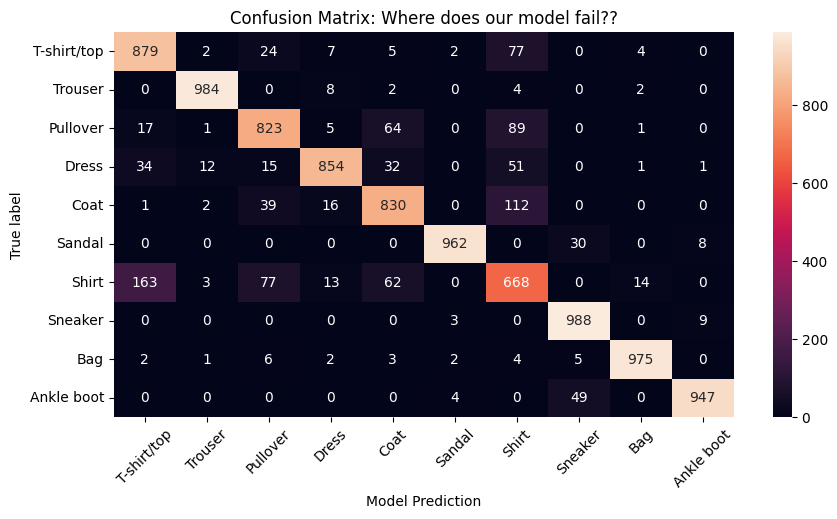

In [50]:
#visualizing where our model fails???
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize = (10,5))
sns.heatmap(cm, fmt = 'd', annot = True, xticklabels= class_names, yticklabels= class_names)
plt.title('Confusion Matrix: Where does our model fail??')
plt.xlabel('Model Prediction')
plt.ylabel('True label')
plt.xticks(rotation = 45)
plt.show()

CNN improved T-shirt classification modestly but did not resolve Shirt/Coat/Pullover confusion as strongly as hypothesized. This suggests either the model lacks sufficient depth/capacity to detect fine features like collar shape and button plackets, or these classes have genuinely overlapping visual signatures even for CNNs at this resolution.